<a href="https://colab.research.google.com/github/ryukios/stat_ML/blob/main/Regras_Associacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
dataset = pd.read_csv('census.csv')

In [4]:
dataset.head()

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


<Axes: ylabel='Frequency'>

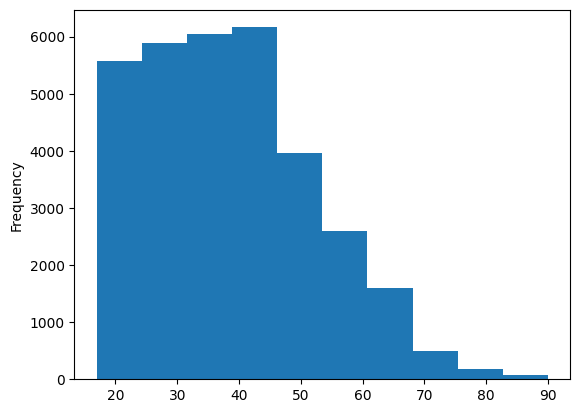

In [14]:
dataset['age'].plot.hist()

In [5]:
subset_age = dataset["age"]
arr = subset_age.to_numpy()
arr

array([39, 50, 38, ..., 58, 22, 52])

In [6]:
frequencia, classes = np.histogram(arr)

In [7]:
frequencia, classes, len(arr)

(array([5570, 5890, 6048, 6163, 3967, 2591, 1595,  496,  174,   67]),
 array([17. , 24.3, 31.6, 38.9, 46.2, 53.5, 60.8, 68.1, 75.4, 82.7, 90. ]),
 32561)

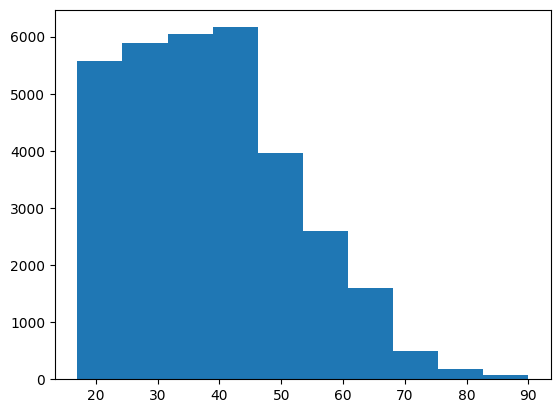

In [8]:
plt.hist(arr, bins = classes);

In [9]:
frequencia, classe = np.histogram(subset_age, bins = 'sturges')
frequencia, classes

(array([3130, 4066, 3376, 4353, 3399, 3876, 2722, 2716, 1924, 1225,  917,
         389,  273,   96,   51,   48]),
 array([17. , 24.3, 31.6, 38.9, 46.2, 53.5, 60.8, 68.1, 75.4, 82.7, 90. ]))

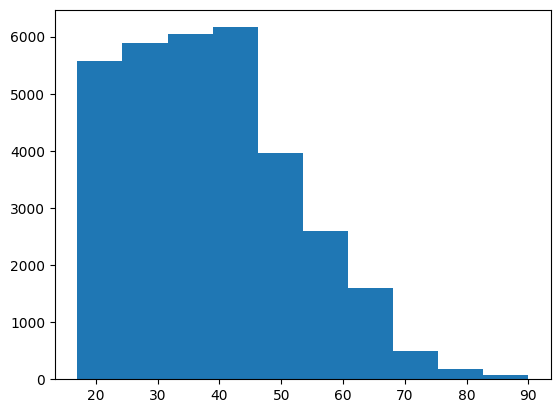

In [10]:
plt.hist(subset_age, classes);

In [11]:
type(subset_age)

pandas.core.series.Series

In [12]:
subset_age.head()

,age
0,39
1,50
2,38
3,53
4,28


<Axes: ylabel='Frequency'>

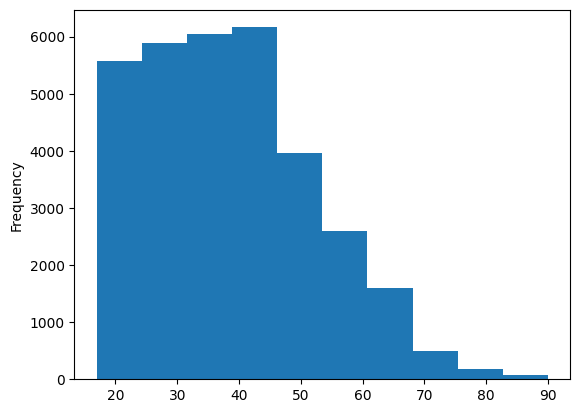

In [13]:
subset_age.plot.hist()

In [16]:
dataset['age'] = pd.cut(dataset['age'], bins=[0,17,25,40,60,90],
                        labels=['Faixa1', 'Faixa2', 'Faixa3', 'Faixa4', 'Faixa5'])

In [17]:
dataset.head()

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
0,Faixa3,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,Faixa4,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,Faixa3,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,Faixa4,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,Faixa3,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [18]:
dataset['age'].unique()

['Faixa3', 'Faixa4', 'Faixa2', 'Faixa5', 'Faixa1']
Categories (5, object): ['Faixa1' < 'Faixa2' < 'Faixa3' < 'Faixa4' < 'Faixa5']

In [21]:
dataset_apriori = dataset[['age', 'workclass', 'education', 'marital-status', 'relationship', 'occupation', 'sex', 'native-country', 'income']]

In [22]:
dataset_apriori.head()

,age,workclass,education,marital-status,relationship,occupation,sex,native-country,income
0,Faixa3,State-gov,Bachelors,Never-married,Not-in-family,Adm-clerical,Male,United-States,<=50K
1,Faixa4,Self-emp-not-inc,Bachelors,Married-civ-spouse,Husband,Exec-managerial,Male,United-States,<=50K
2,Faixa3,Private,HS-grad,Divorced,Not-in-family,Handlers-cleaners,Male,United-States,<=50K
3,Faixa4,Private,11th,Married-civ-spouse,Husband,Handlers-cleaners,Male,United-States,<=50K
4,Faixa3,Private,Bachelors,Married-civ-spouse,Wife,Prof-specialty,Female,Cuba,<=50K


In [23]:
dataset.shape


(32561, 15)

In [24]:
dataset_apriori = dataset_apriori.sample(n = 1000)
dataset_apriori.shape

(1000, 9)

In [39]:
transacoes = []
for i in range(dataset_apriori.shape[0]):
    transacoes.append([str(dataset_apriori.values[i, j]) for j in range(dataset_apriori.shape[1])])

In [27]:
len(transacoes)

1000

In [32]:
print(transacoes[:2])

[<generator object <genexpr> at 0x7b50e2567a00>, <generator object <genexpr> at 0x7b50cc399fc0>]


In [33]:
!pip install apyori

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=8d20c29ea9d2193b7e16e80342de822812ee556b9613211cf8175255cc719ea7
  Stored in directory: /root/.cache/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori


In [43]:
from apyori import apriori

regras = apriori(
    transacoes,
    min_support=0.3,
    min_confidence=0.2
)

resultados = list(regras)

# ver algumas regras
for r in resultados[:10]:
    print(r)



RelationRecord(items=frozenset({' <=50K'}), support=0.75, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({' <=50K'}), confidence=0.75, lift=1.0)])
RelationRecord(items=frozenset({' Female'}), support=0.307, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({' Female'}), confidence=0.307, lift=1.0)])
RelationRecord(items=frozenset({' HS-grad'}), support=0.32, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({' HS-grad'}), confidence=0.32, lift=1.0)])
RelationRecord(items=frozenset({' Husband'}), support=0.442, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({' Husband'}), confidence=0.442, lift=1.0)])
RelationRecord(items=frozenset({' Male'}), support=0.693, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({' Male'}), confidence=0.693, lift=1.0)])
RelationRecord(items=frozenset({' Married-civ-spouse'}), support=0.498, ordered_s

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag